In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('average_price.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()


Shape: (144630, 7)
Columns: ['Date', 'Region_Name', 'Area_Code', 'Average_Price', 'Monthly_Change', 'Annual_Change', 'Average_Price_SA']


,Date,Region_Name,Area_Code,Average_Price,Monthly_Change,Annual_Change,Average_Price_SA
0,1968-04-01,Northern Ireland,N92000001,3465,NaN,NaN,NaN
1,1968-04-01,England,E92000001,3218,NaN,NaN,NaN
2,1968-04-01,Wales,W92000004,2732,NaN,NaN,NaN
3,1968-04-01,Scotland,S92000003,2738,NaN,NaN,NaN
4,1968-04-01,London,E12000007,4730,NaN,NaN,NaN


# UK House Price Trends Analysis

Analysis of HM Land Registry UK House Price Index data (1968-2025),
looking at how average house prices have changed across UK regions over time.

## 1. Cleaning


In [8]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df = df.dropna(subset=['Average_Price'])

main_regions = ['United Kingdom', 'England', 'Scotland', 'Wales',
                'Northern Ireland', 'London', 'South East', 'South West',
                'East of England', 'East Midlands', 'West Midlands',
                'Yorkshire and The Humber', 'North West', 'North East']

df_main = df[df['Region_Name'].isin(main_regions)].copy()

print('Date range:', df_main['Date'].min().date(), 'to', df_main['Date'].max().date())
print('Regions:', df_main['Region_Name'].nunique())
df_main.head()


Date range: 1968-04-01 to 2025-01-01
Regions: 14


,Date,Region_Name,Area_Code,Average_Price,Monthly_Change,Annual_Change,Average_Price_SA,Year
0,1968-04-01,Northern Ireland,N92000001,3465,NaN,NaN,NaN,1968
1,1968-04-01,England,E92000001,3218,NaN,NaN,NaN,1968
2,1968-04-01,Wales,W92000004,2732,NaN,NaN,NaN,1968
3,1968-04-01,Scotland,S92000003,2738,NaN,NaN,NaN,1968
4,1968-04-01,London,E12000007,4730,NaN,NaN,NaN,1968


## 2. Summary Statistics


In [9]:
latest_year = df_main['Year'].max()
latest = df_main[df_main['Year'] == latest_year].groupby('Region_Name')['Average_Price'].mean().round(0).sort_values(ascending=False)
print(f'Average prices by region in {latest_year}:')
print(latest)


Average prices by region in 2025:
Region_Name
London                      563899.0
South East                  386103.0
East of England             338657.0
South West                  307233.0
England                     291397.0
United Kingdom              268548.0
East Midlands               241159.0
West Midlands               231270.0
North West                  210259.0
Wales                       209579.0
Yorkshire and The Humber    202930.0
Scotland                    187434.0
Northern Ireland            183259.0
North East                  161373.0
Name: Average_Price, dtype: float64


	Wrote down the top 1 and bottom 1 regions (you'll need them for findings)
  London                    563899.0
South East                  386103.0


## 3. National Price Trend


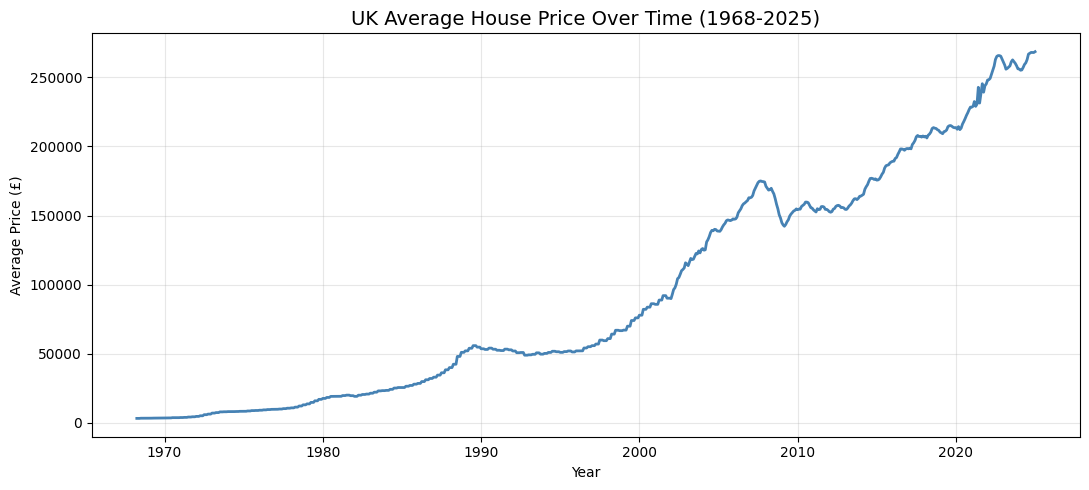

In [10]:
uk_data = df_main[df_main['Region_Name'] == 'United Kingdom'].sort_values('Date')

plt.figure(figsize=(11, 5))
plt.plot(uk_data['Date'], uk_data['Average_Price'], linewidth=2, color='steelblue')
plt.title('UK Average House Price Over Time (1968-2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Price (£)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart_national.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Regional Comparison (Latest Year)

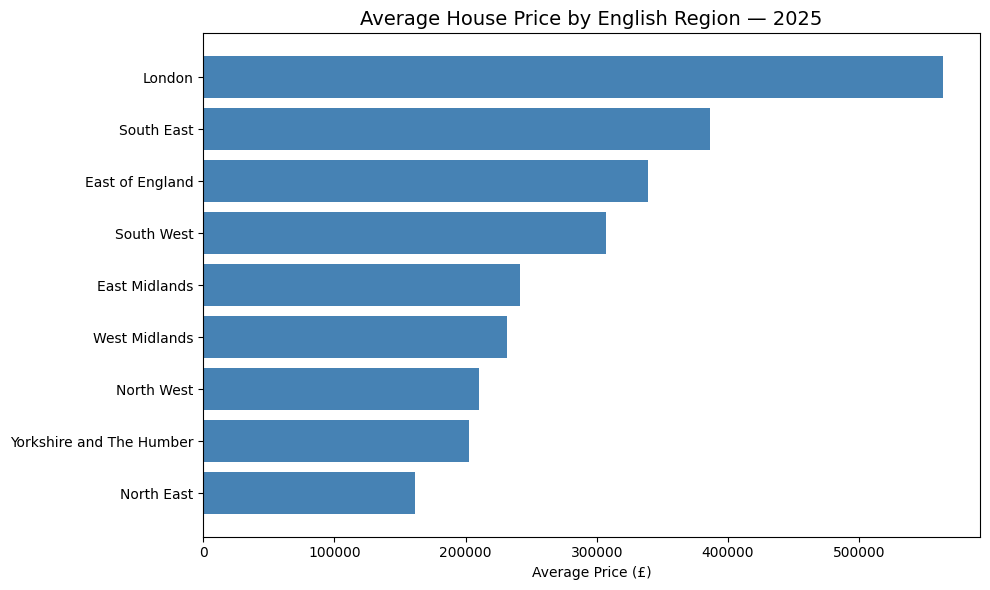

In [11]:
english_regions = ['London', 'South East', 'East of England', 'South West',
                   'East Midlands', 'West Midlands', 'Yorkshire and The Humber',
                   'North West', 'North East']

latest_data = df_main[(df_main['Year'] == latest_year) &
                      (df_main['Region_Name'].isin(english_regions))]
regional_avg = latest_data.groupby('Region_Name')['Average_Price'].mean().sort_values()

plt.figure(figsize=(10, 6))
plt.barh(regional_avg.index, regional_avg.values, color='steelblue')
plt.title(f'Average House Price by English Region — {latest_year}', fontsize=14)
plt.xlabel('Average Price (£)')
plt.tight_layout()
plt.savefig('chart_regional.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Long-Term Growth Comparison

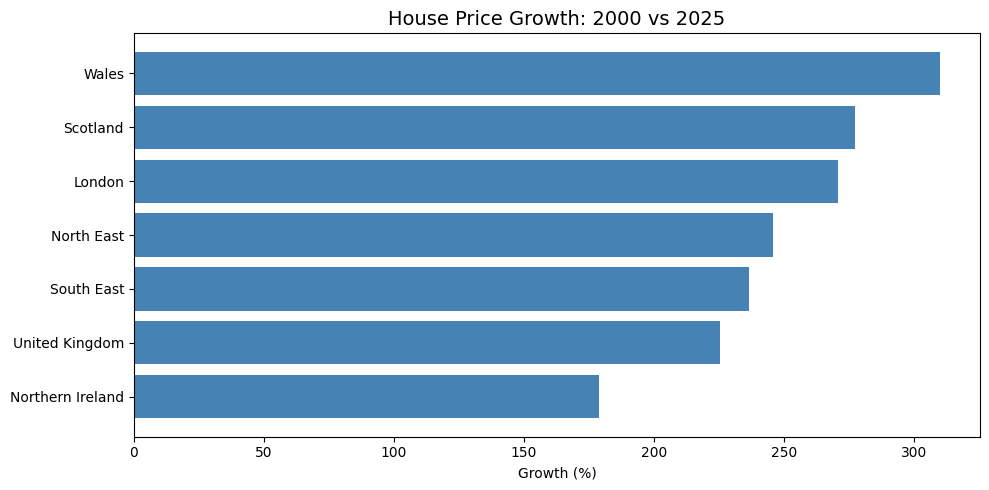

          Region  Growth %
Northern Ireland     178.8
  United Kingdom     225.4
      South East     236.6
      North East     245.9
          London     270.9
        Scotland     277.6
           Wales     310.0


In [12]:
target_regions = ['United Kingdom', 'London', 'South East', 'North East',
                  'Scotland', 'Wales', 'Northern Ireland']

growth_data = []
for region in target_regions:
    region_df = df_main[df_main['Region_Name'] == region]
    price_2000 = region_df[region_df['Year'] == 2000]['Average_Price'].mean()
    price_latest = region_df[region_df['Year'] == latest_year]['Average_Price'].mean()
    if pd.notna(price_2000) and price_2000 > 0:
        growth_pct = ((price_latest - price_2000) / price_2000) * 100
        growth_data.append({'Region': region, 'Growth %': round(growth_pct, 1)})

growth_df = pd.DataFrame(growth_data).sort_values('Growth %')

plt.figure(figsize=(10, 5))
plt.barh(growth_df['Region'], growth_df['Growth %'], color='steelblue')
plt.title('House Price Growth: 2000 vs ' + str(latest_year), fontsize=14)
plt.xlabel('Growth (%)')
plt.tight_layout()
plt.savefig('chart_growth.png', dpi=100, bbox_inches='tight')
plt.show()

print(growth_df.to_string(index=False))



## 6. Statistical Analysis

In [13]:
pivot = df_main[df_main['Region_Name'].isin(english_regions + ['United Kingdom'])].pivot_table(
    index='Date', columns='Region_Name', values='Average_Price')

correlation_with_uk = pivot.corr()['United Kingdom'].drop('United Kingdom').sort_values(ascending=False)
print('Correlation of each region with UK national average:')
print(correlation_with_uk.round(3))

print('\nLatest year price distribution across regions:')
print(latest.describe().round(0))


Correlation of each region with UK national average:
Region_Name
South West                  0.999
East Midlands               0.998
South East                  0.996
East of England             0.996
Yorkshire and The Humber    0.995
West Midlands               0.995
North West                  0.988
London                      0.987
North East                  0.958
Name: United Kingdom, dtype: float64

Latest year price distribution across regions:
count        14.0
mean     270221.0
std      106195.0
min      161373.0
25%      204592.0
50%      236214.0
75%      303274.0
max      563899.0
Name: Average_Price, dtype: float64


In [14]:
# Get exact figures for the README
uk_2000 = df_main[(df_main['Region_Name'] == 'United Kingdom') & (df_main['Year'] == 2000)]['Average_Price'].mean()
uk_latest = df_main[(df_main['Region_Name'] == 'United Kingdom') & (df_main['Year'] == latest_year)]['Average_Price'].mean()
growth = ((uk_latest - uk_2000) / uk_2000) * 100

print(f"UK 2000 average: £{round(uk_2000):,}")
print(f"UK {latest_year} average: £{round(uk_latest):,}")
print(f"Growth: {round(growth, 1)}%")

UK 2000 average: £82,534
UK 2025 average: £268,548
Growth: 225.4%


In [15]:
top_growth = growth_df.sort_values('Growth %', ascending=False).iloc[0]
print(f"Strongest growth since 2000: {top_growth['Region']} at {top_growth['Growth %']}%")

Strongest growth since 2000: Wales at 310.0%


## 7. Saving for SQL and BI Tools

In [16]:
import sqlite3

df_main.to_csv('uk_house_prices_cleaned.csv', index=False)

conn = sqlite3.connect('house_prices.db')
df_main.to_sql('prices', conn, if_exists='replace', index=False)
print('Saved cleaned CSV and SQLite database')
print(f'Total rows in database: {len(df_main)}')


Saved cleaned CSV and SQLite database
Total rows in database: 8042


In [17]:
# findings
uk_2000 = df_main[(df_main['Region_Name']=='United Kingdom') & (df_main['Year']==2000)]['Average_Price'].mean()
uk_latest = df_main[(df_main['Region_Name']=='United Kingdom') & (df_main['Year']==latest_year)]['Average_Price'].mean()
growth = ((uk_latest - uk_2000) / uk_2000) * 100

top_growth = growth_df.sort_values('Growth %', ascending=False).iloc[0]
lowest_corr = correlation_with_uk.min()

print(f"FINDING 1: UK rose from £{round(uk_2000):,} in 2000 to £{round(uk_latest):,} in {latest_year} — {round(growth, 1)}% increase")
print(f"FINDING 2: Highest growth region — {top_growth['Region']} at {top_growth['Growth %']}%")
print(f"FINDING 3: Lowest regional correlation with UK average — {round(lowest_corr, 3)}")

FINDING 1: UK rose from £82,534 in 2000 to £268,548 in 2025 — 225.4% increase
FINDING 2: Highest growth region — Wales at 310.0%
FINDING 3: Lowest regional correlation with UK average — 0.958


In [18]:
london_2025 = df_main[(df_main['Region_Name'] == 'London') & (df_main['Year'] == 2025)]['Average_Price'].mean()
uk_2025 = df_main[(df_main['Region_Name'] == 'United Kingdom') & (df_main['Year'] == 2025)]['Average_Price'].mean()
gap = london_2025 - uk_2025

print(f"London 2025: £{round(london_2025):,}")
print(f"UK 2025: £{round(uk_2025):,}")
print(f"Gap: £{round(gap):,}")

London 2025: £563,899
UK 2025: £268,548
Gap: £295,351
